## Libraries

In [1]:
import pandas as pd
import geopandas as gpd
import os
import json
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import math
import numpy as np

## Linking Functions notebook

In [2]:
# Adding path to system
import sys
sys.path.append(r"C:\\Users\\eliya\\Documents\\עבודה\\עוזר מחקר\\4. פרויקטים\\1. quality measures\\1. Feature Completeness")

In [3]:
# Importing relevant functions
import importlib
from functions import get_len, get_count, get_area, get_add_from_cum, semi_norm_mix_transform, wrap_api_query, generate_measure_sample_plot

## Update function

In [ ]:
# Generate a mixed transformation ratio of cumulative size divided by cumulative counts
def semi_norm_mix_transform(count_gdf, size_gdf, alpha=0.3, time_thresh=2, saturation_thresh=1.5, return_full=False):
    '''
    Receives two GeoDataFrames (assumes identical timestamps and geometry):
    1) A cumulative count of added features by timestamps
    2) A cumulative length of all features by timestamps

    The function converts timestamp to actual datetime format, transforms the values to a mixed normalized percentage of added value (length / area) per each added unit.
    After that, the function applies the following statistical test:
    
    `If all cumulative change percentage is below some alpha (default: 30%) for a stable time period (default: 2 years), the data is considered saturated.`
    
    For saturated data, the function then computes the saturation point (1st month in stable period) and calculates cumulative percentage up to that point.

    In all cases, the output is a DataFrame:
    * If not saturated --> the merged DataFrame, with updated timstamps and calculations.
    * If saturated --> can either return only values up to the saturation point + maximum value (default) or return the entire data with reference to the saturation point.
    
    Dependencies:
    * pandas as pd
    '''
    # Fix timestamp
    count_gdf['timestamp'] = pd.to_datetime(count_gdf['timestamp'])
    size_gdf['timestamp'] = pd.to_datetime(size_gdf['timestamp'])

    # Sort both DataFrames by timestamp and reset index for proper alignment
    count_gdf = count_gdf.sort_values('timestamp').reset_index(drop=True)
    size_gdf = size_gdf.sort_values('timestamp').reset_index(drop=True)

    # Merge Dataframes
    gdf = count_gdf.copy().rename(columns={'value' : 'count'}) # Copy DF and rename count column
    gdf['size'] = size_gdf['value'] # Append size column
    
    # Transform values
    gdf['cumulative_percentage'] = gdf['size'] / gdf['count']
    gdf['cumulative_percentage'] = gdf['cumulative_percentage'].fillna(0) # Deal with periods without addition
    gdf['normalized_cum_per'] = gdf['cumulative_percentage'] / gdf['cumulative_percentage'].max()

    # Apply completeness test for level alpha
    gdf['test'] = (gdf['normalized_cum_per'] < alpha) # Boolean term for each date in data

    ## Iterate backwards in data to find stability period
    i = -1 # Running index (from end)
    test = gdf['test'].iat[i] # Running boolean test answer (from end)
    while test:
        try: # Update index
            i -= 1
            test = gdf['test'].iat[i]
        
        except IndexError: # Break loop if at first index
            break
    
    if i == -1:
        # Deal with last value percentage being greater than alpha (i.e. no stable period)
        print('Data incomplete: no stable period')
        return gdf
    
    stable = gdf.iloc[i+1:].copy() # Extract stable period

    ## If stable period shorter than given time threshold --> data is incomplete
    if (stable['timestamp'].max() - stable['timestamp'].min()) < pd.Timedelta(days=time_thresh*365):
        print('Data incomplete: stable period shorter than threshold')
        return gdf

    ## For complete data
    else:
        # Extract saturated value
        saturation_point = stable.iloc[0]

        # Calculate saturation levels
        gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
        
         # Extract emprical maximal value
        real_max = gdf.iloc[-1]
      
        # Verify small absolute addition
        if (real_max['percentage_until_saturation'] >= saturation_thresh):
            print('Data incomplete: stable addition larger than threshold')
            return gdf
        
        # Extract 80% saturation timestamp
        saturated_time = gdf[gdf['percentage_until_saturation'] >= 0.8]['timestamp'].iloc[0]
        print(f'Date complete:\nPolygon 80% saturated at {saturated_time}')

        ### Return entire gdf if requested
        if return_full:
            return gdf
        
        ### Return compact gdf (default)
        else:
            # Filter data until saturation
            saturated = gdf.iloc[:i+1].copy()
        
            # Concatenate empirical maximal value
            saturated = pd.concat([saturated,
                                   pd.DataFrame([real_max])],
                                   ignore_index=True)       
            return saturated

## Tests

In [6]:
counts_rds = pd.read_csv(r"C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\2) Events export\road_counts.csv")
lengths = pd.read_csv(r"C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\2) Events export\road_lengths.csv")
counts_bld = pd.read_csv(r"C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\2) Events export\building_counts.csv")
areas = pd.read_csv(r"C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\2) Events export\building_areas.csv")

In [21]:
# Test for lists for plots
roads_test = []
bldgs_test = []

for idx, count_group in counts_rds.groupby('idx'):
    len_group = lengths[lengths['idx'] == idx].copy() # grouping length dataframe entries
    t1 = semi_norm_mix_transform(count_group, len_group, alpha=0.1, return_full=True)
    t1.loc[:, 'idx'] = idx  # preserve original index
    roads_test.append(t1)

for idx, count_group in counts_bld.groupby('idx'):
    area_group = areas[areas['idx'] == idx].copy() # grouping area dataframe entries
    t2 = semi_norm_mix_transform(count_group, area_group, alpha=0.1, return_full=True)
    t2.loc[:, 'idx'] = idx # preserve original index
    bldgs_test.append(t2)

Data incomplete: stable addition larger than threshold
Data incomplete: stable period shorter than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Polygon 80% saturated at 2019-04-01 00:00:00+00:00
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: no stable period
Data incomplete: no stable period
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: no stable period
Data incomplete: stable

In [22]:
len(roads_test)

446

## Plots

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


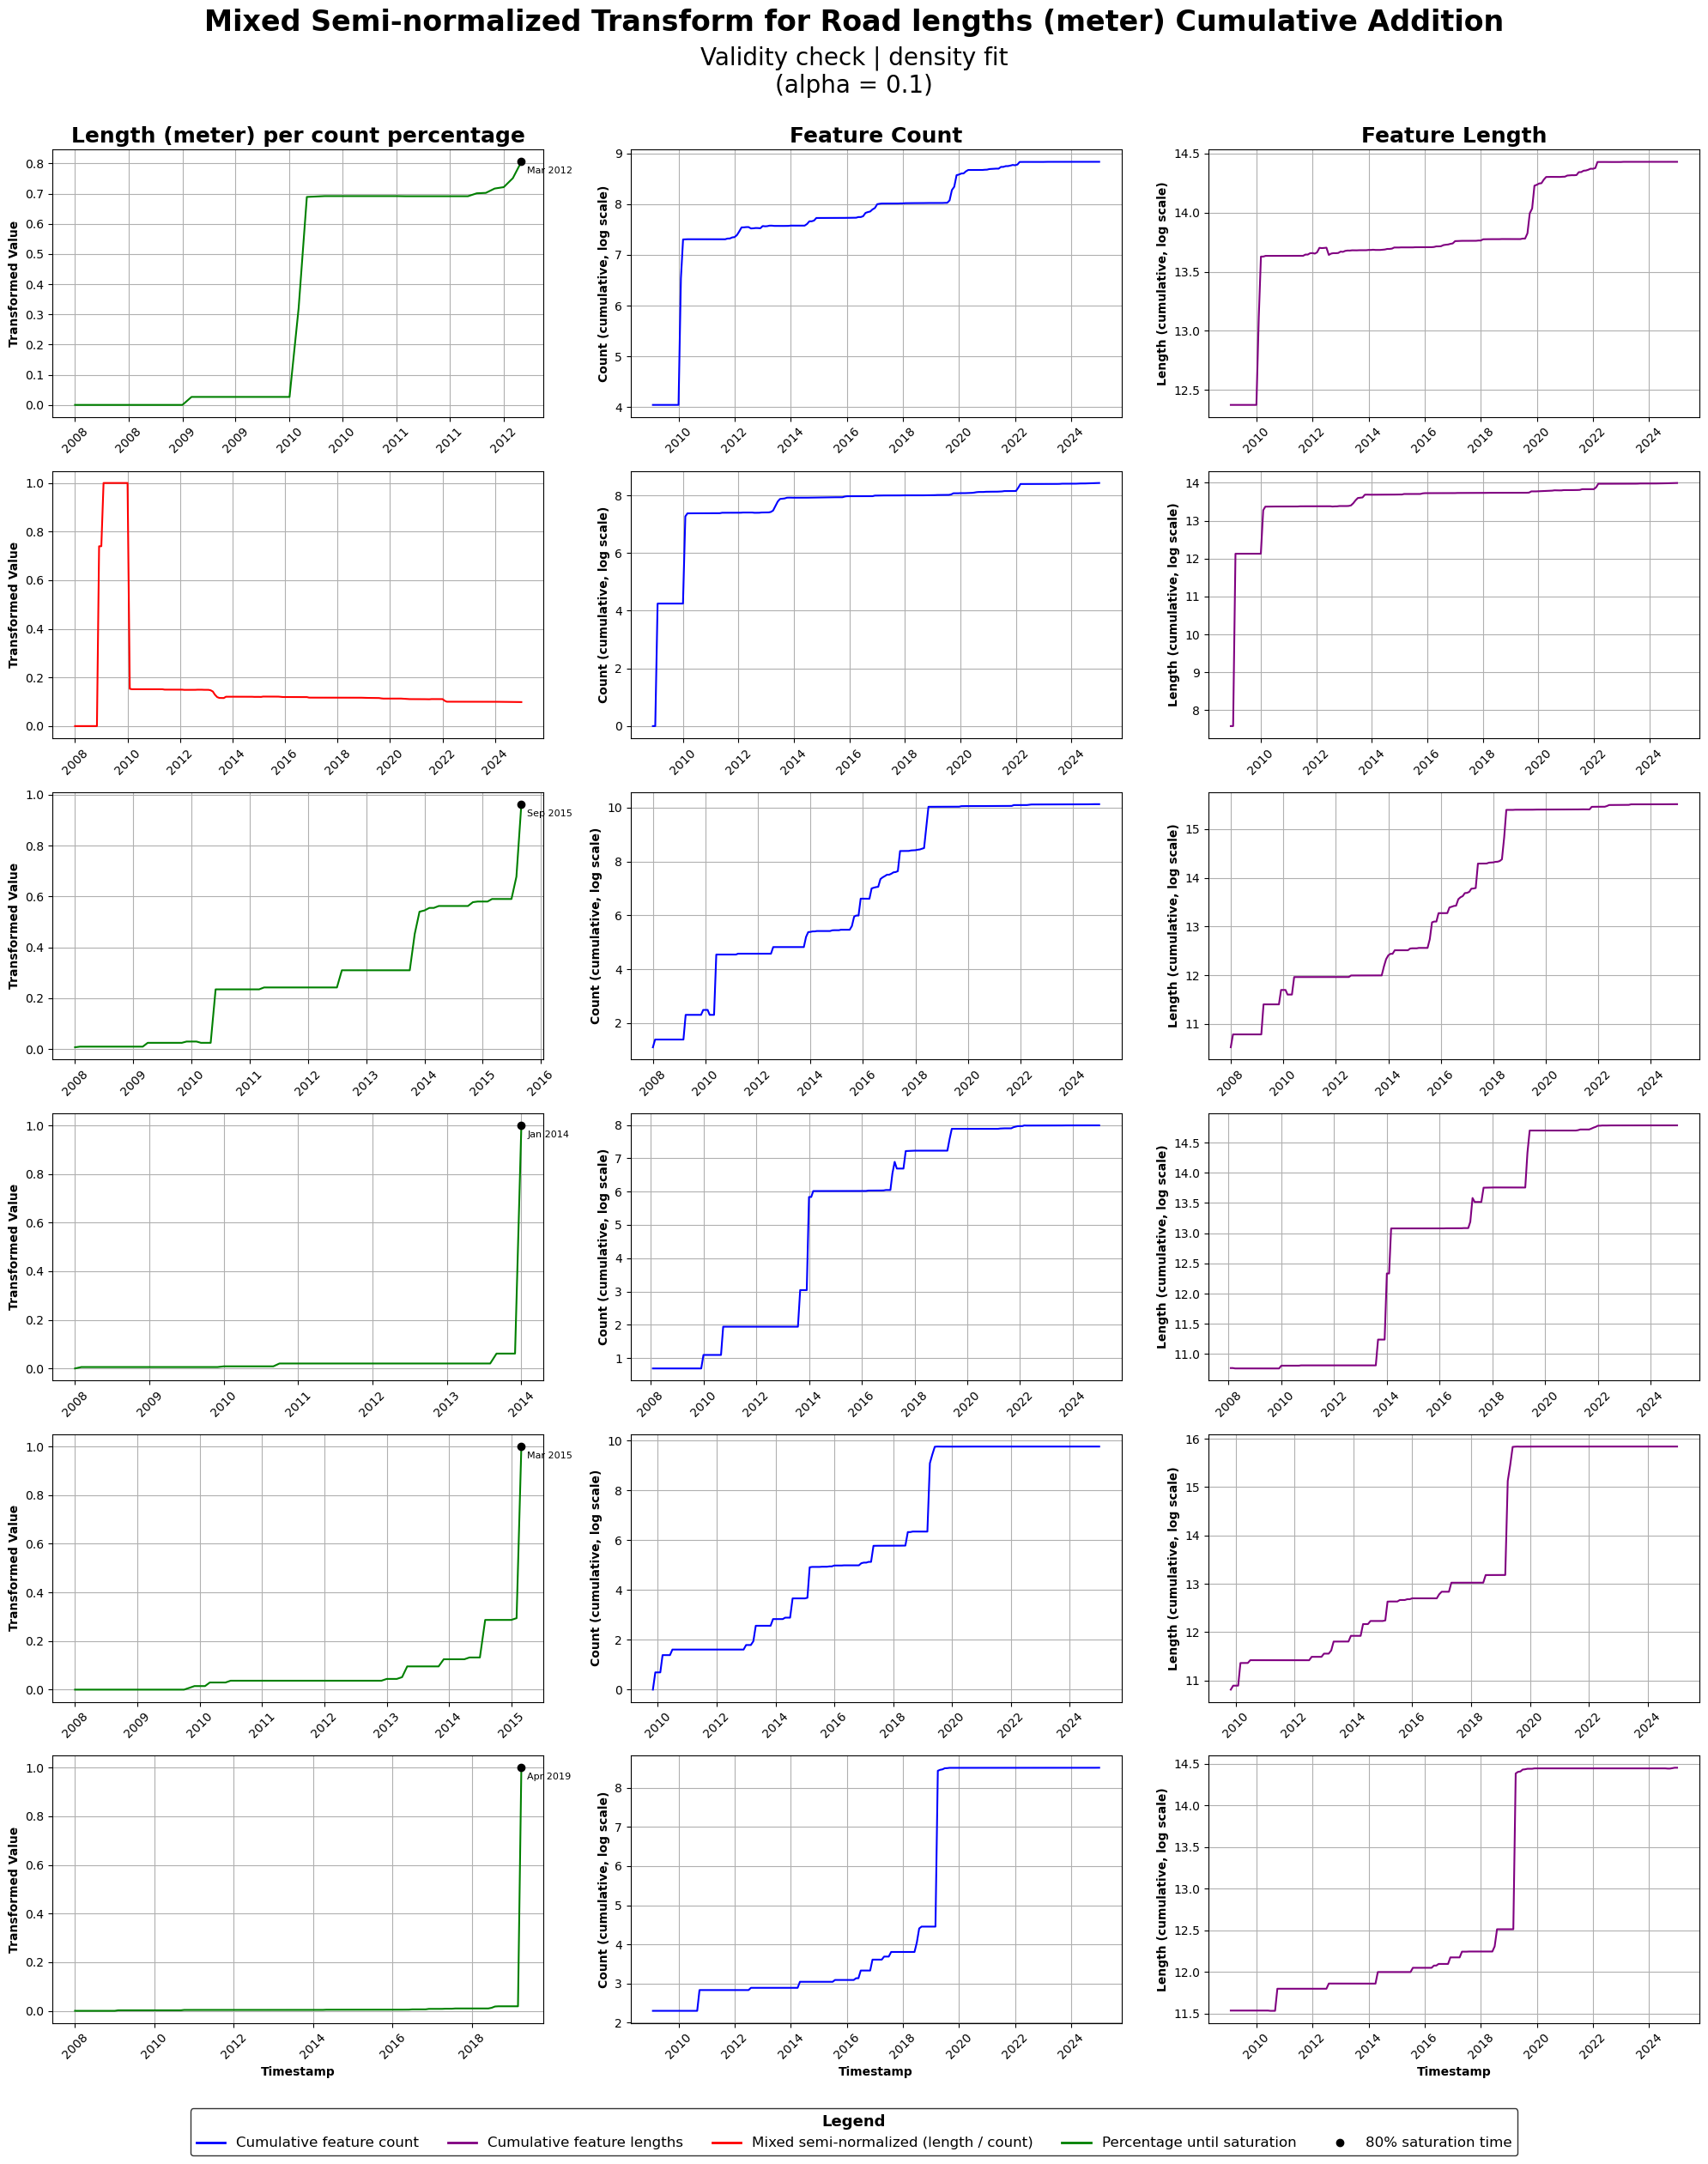

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


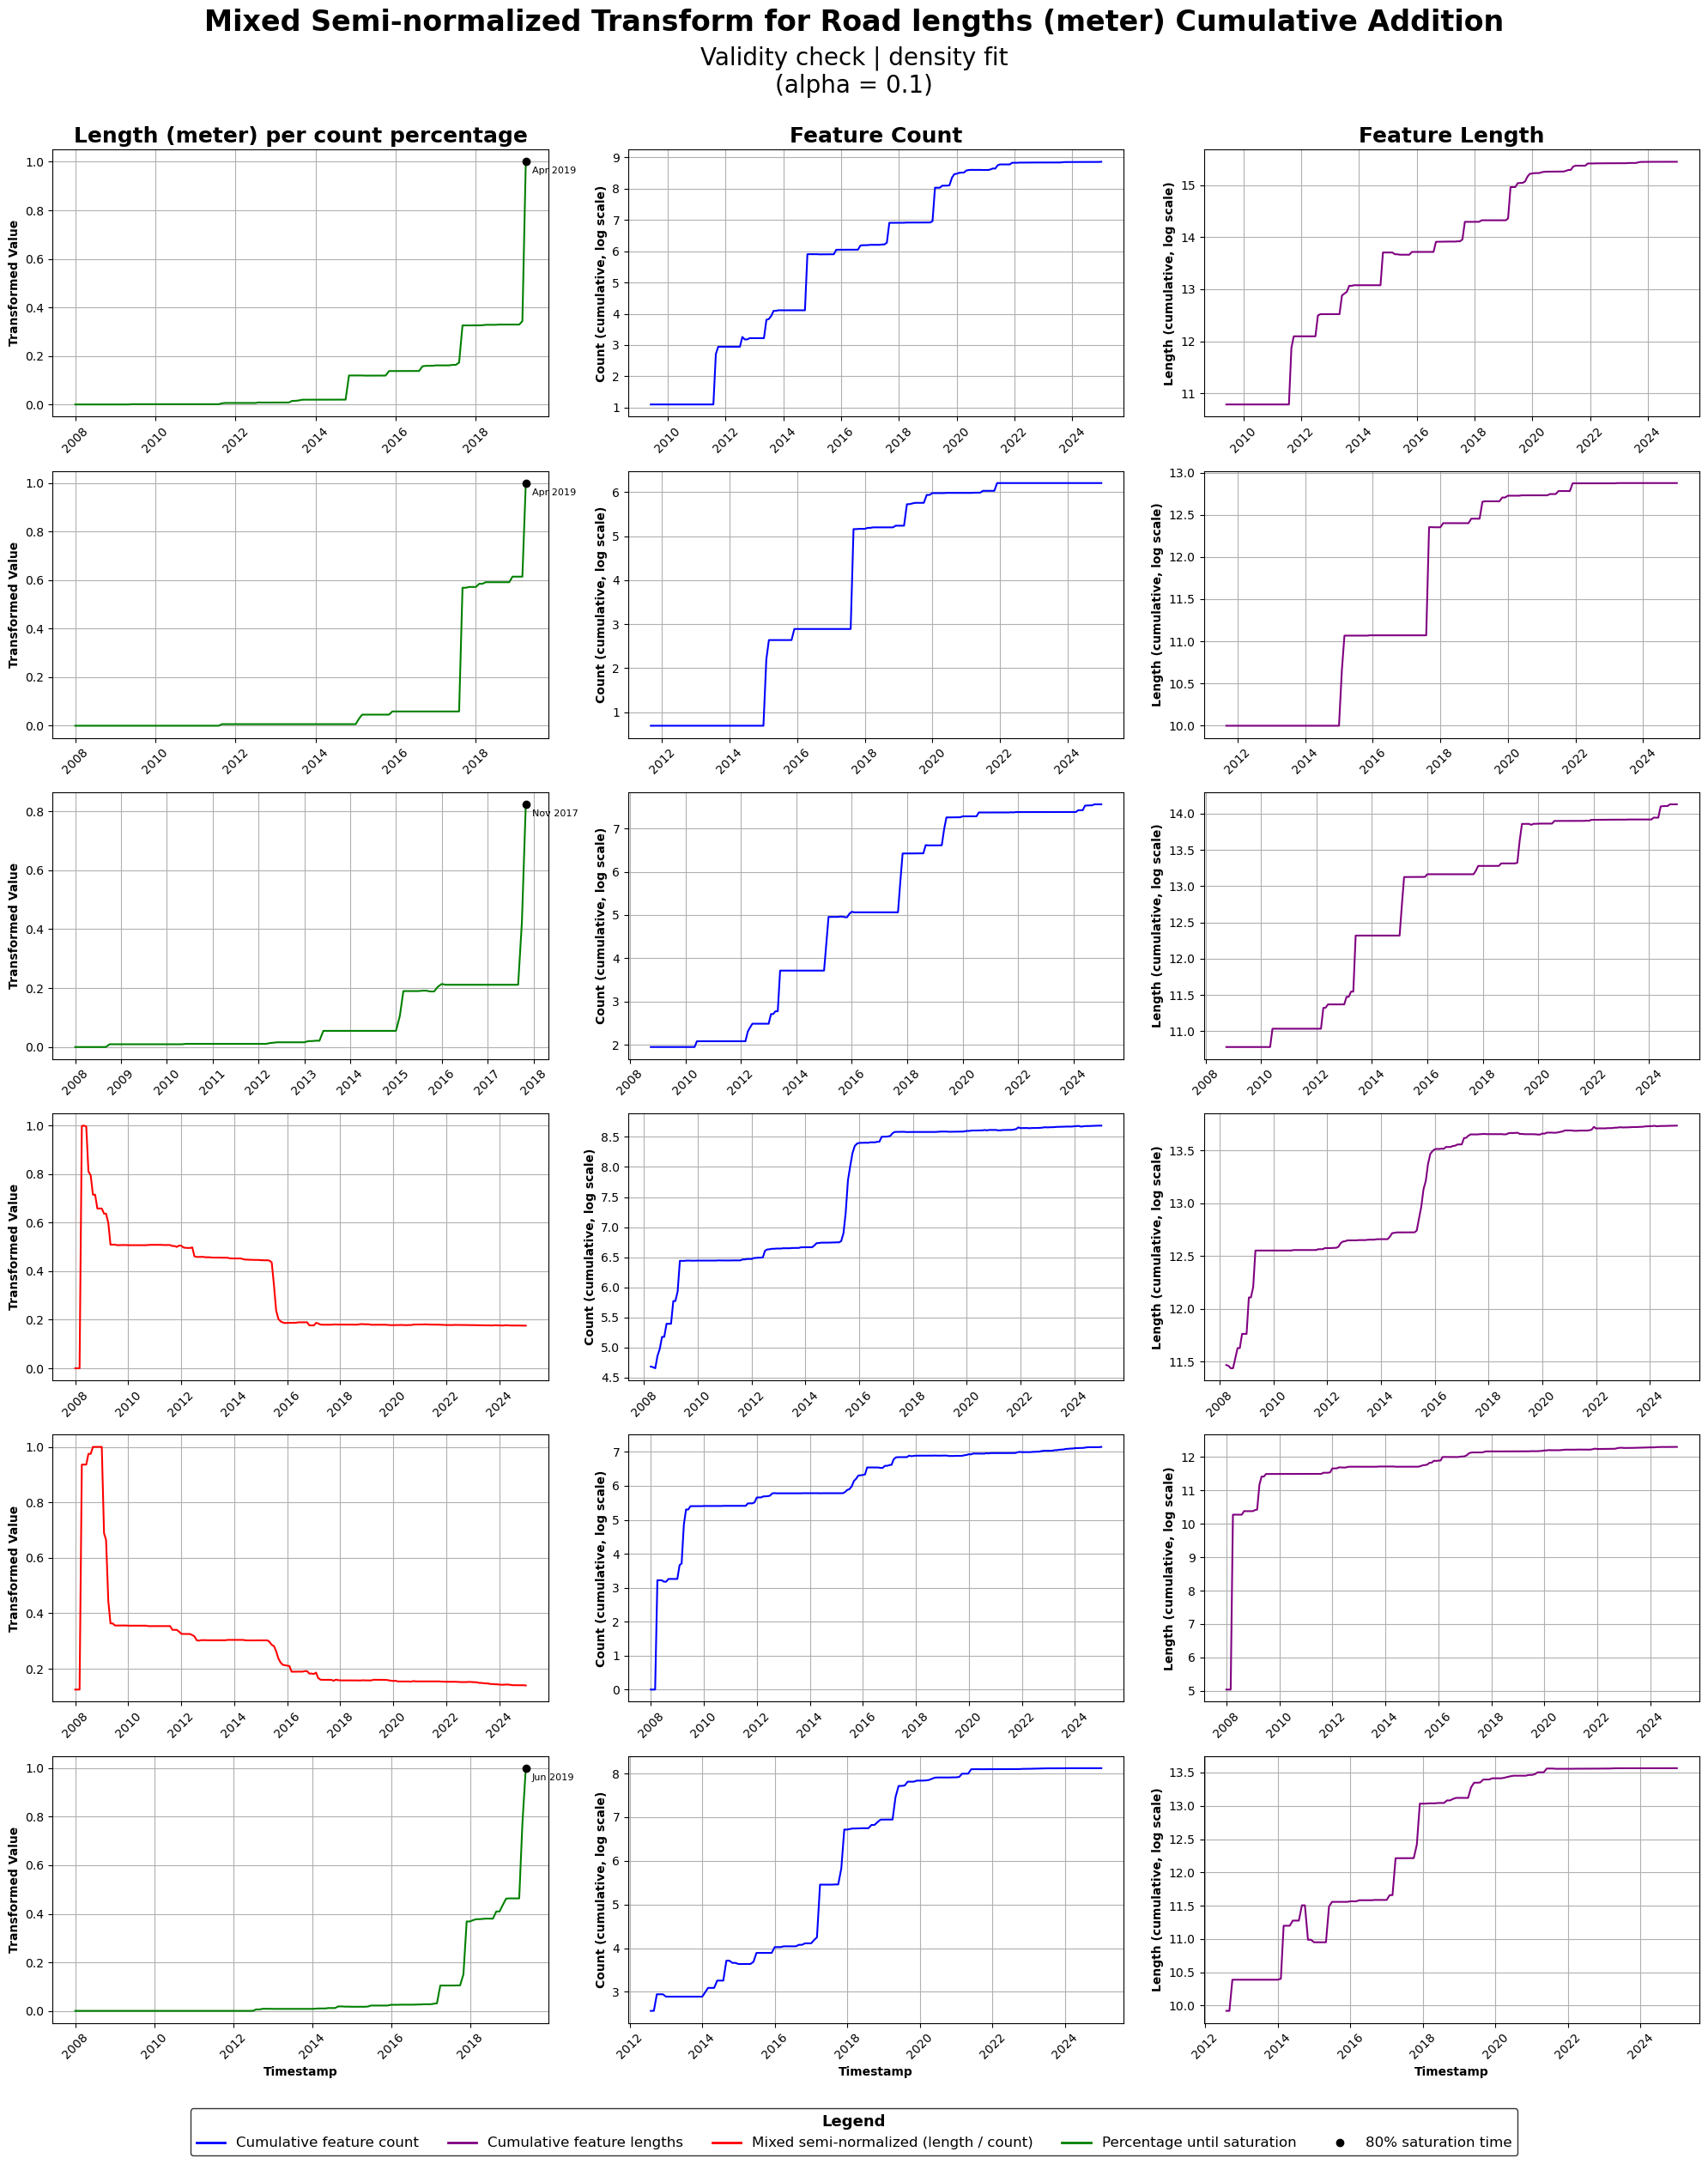

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


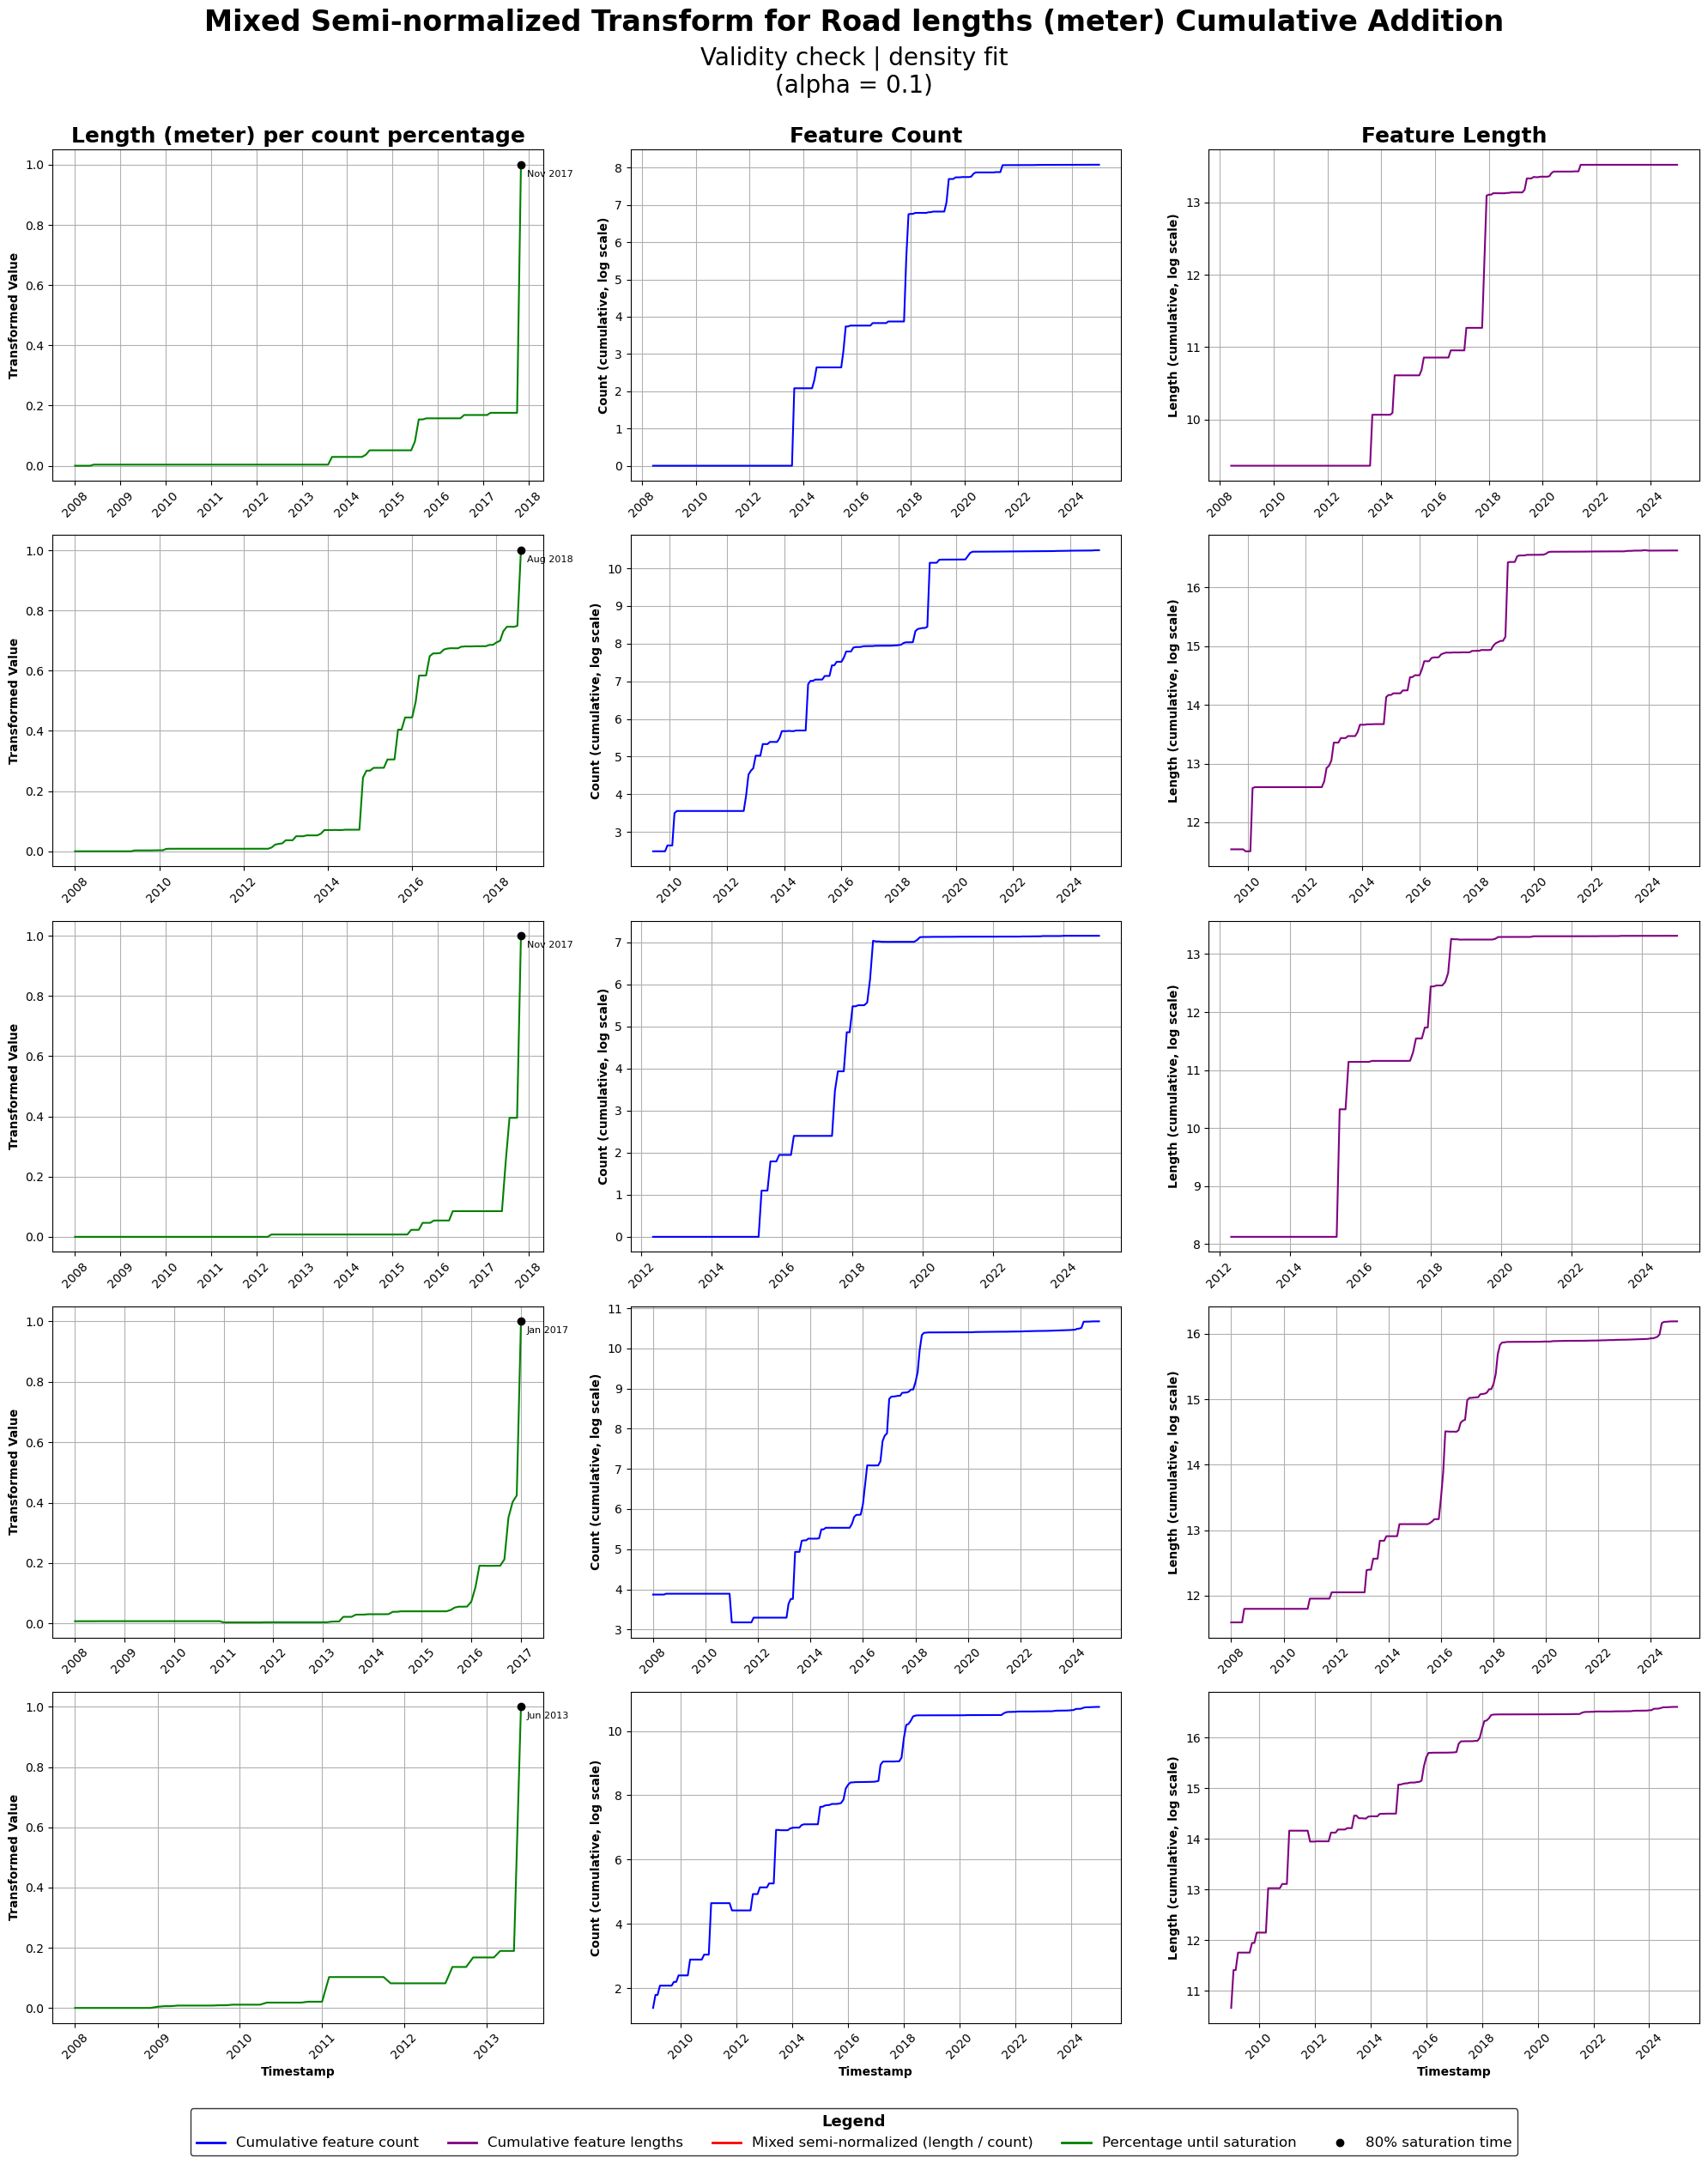

In [23]:
_ = generate_measure_sample_plot(roads_test[0:6], subtitle='Validity check | density fit\n(alpha = 0.1)').savefig(f'plots\\roads_measure_density_fit_1.png', dpi=300, bbox_inches='tight')
_ = generate_measure_sample_plot(roads_test[6:12], subtitle='Validity check | density fit\n(alpha = 0.1)').savefig(f'plots\\roads_measure_density_fit_2.png', dpi=300, bbox_inches='tight')
_ = generate_measure_sample_plot(roads_test[12:18], n=5, subtitle='Validity check | density fit\n(alpha = 0.1)').savefig(f'plots\\roads_measure_density_fit_3.png', dpi=300, bbox_inches='tight')

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


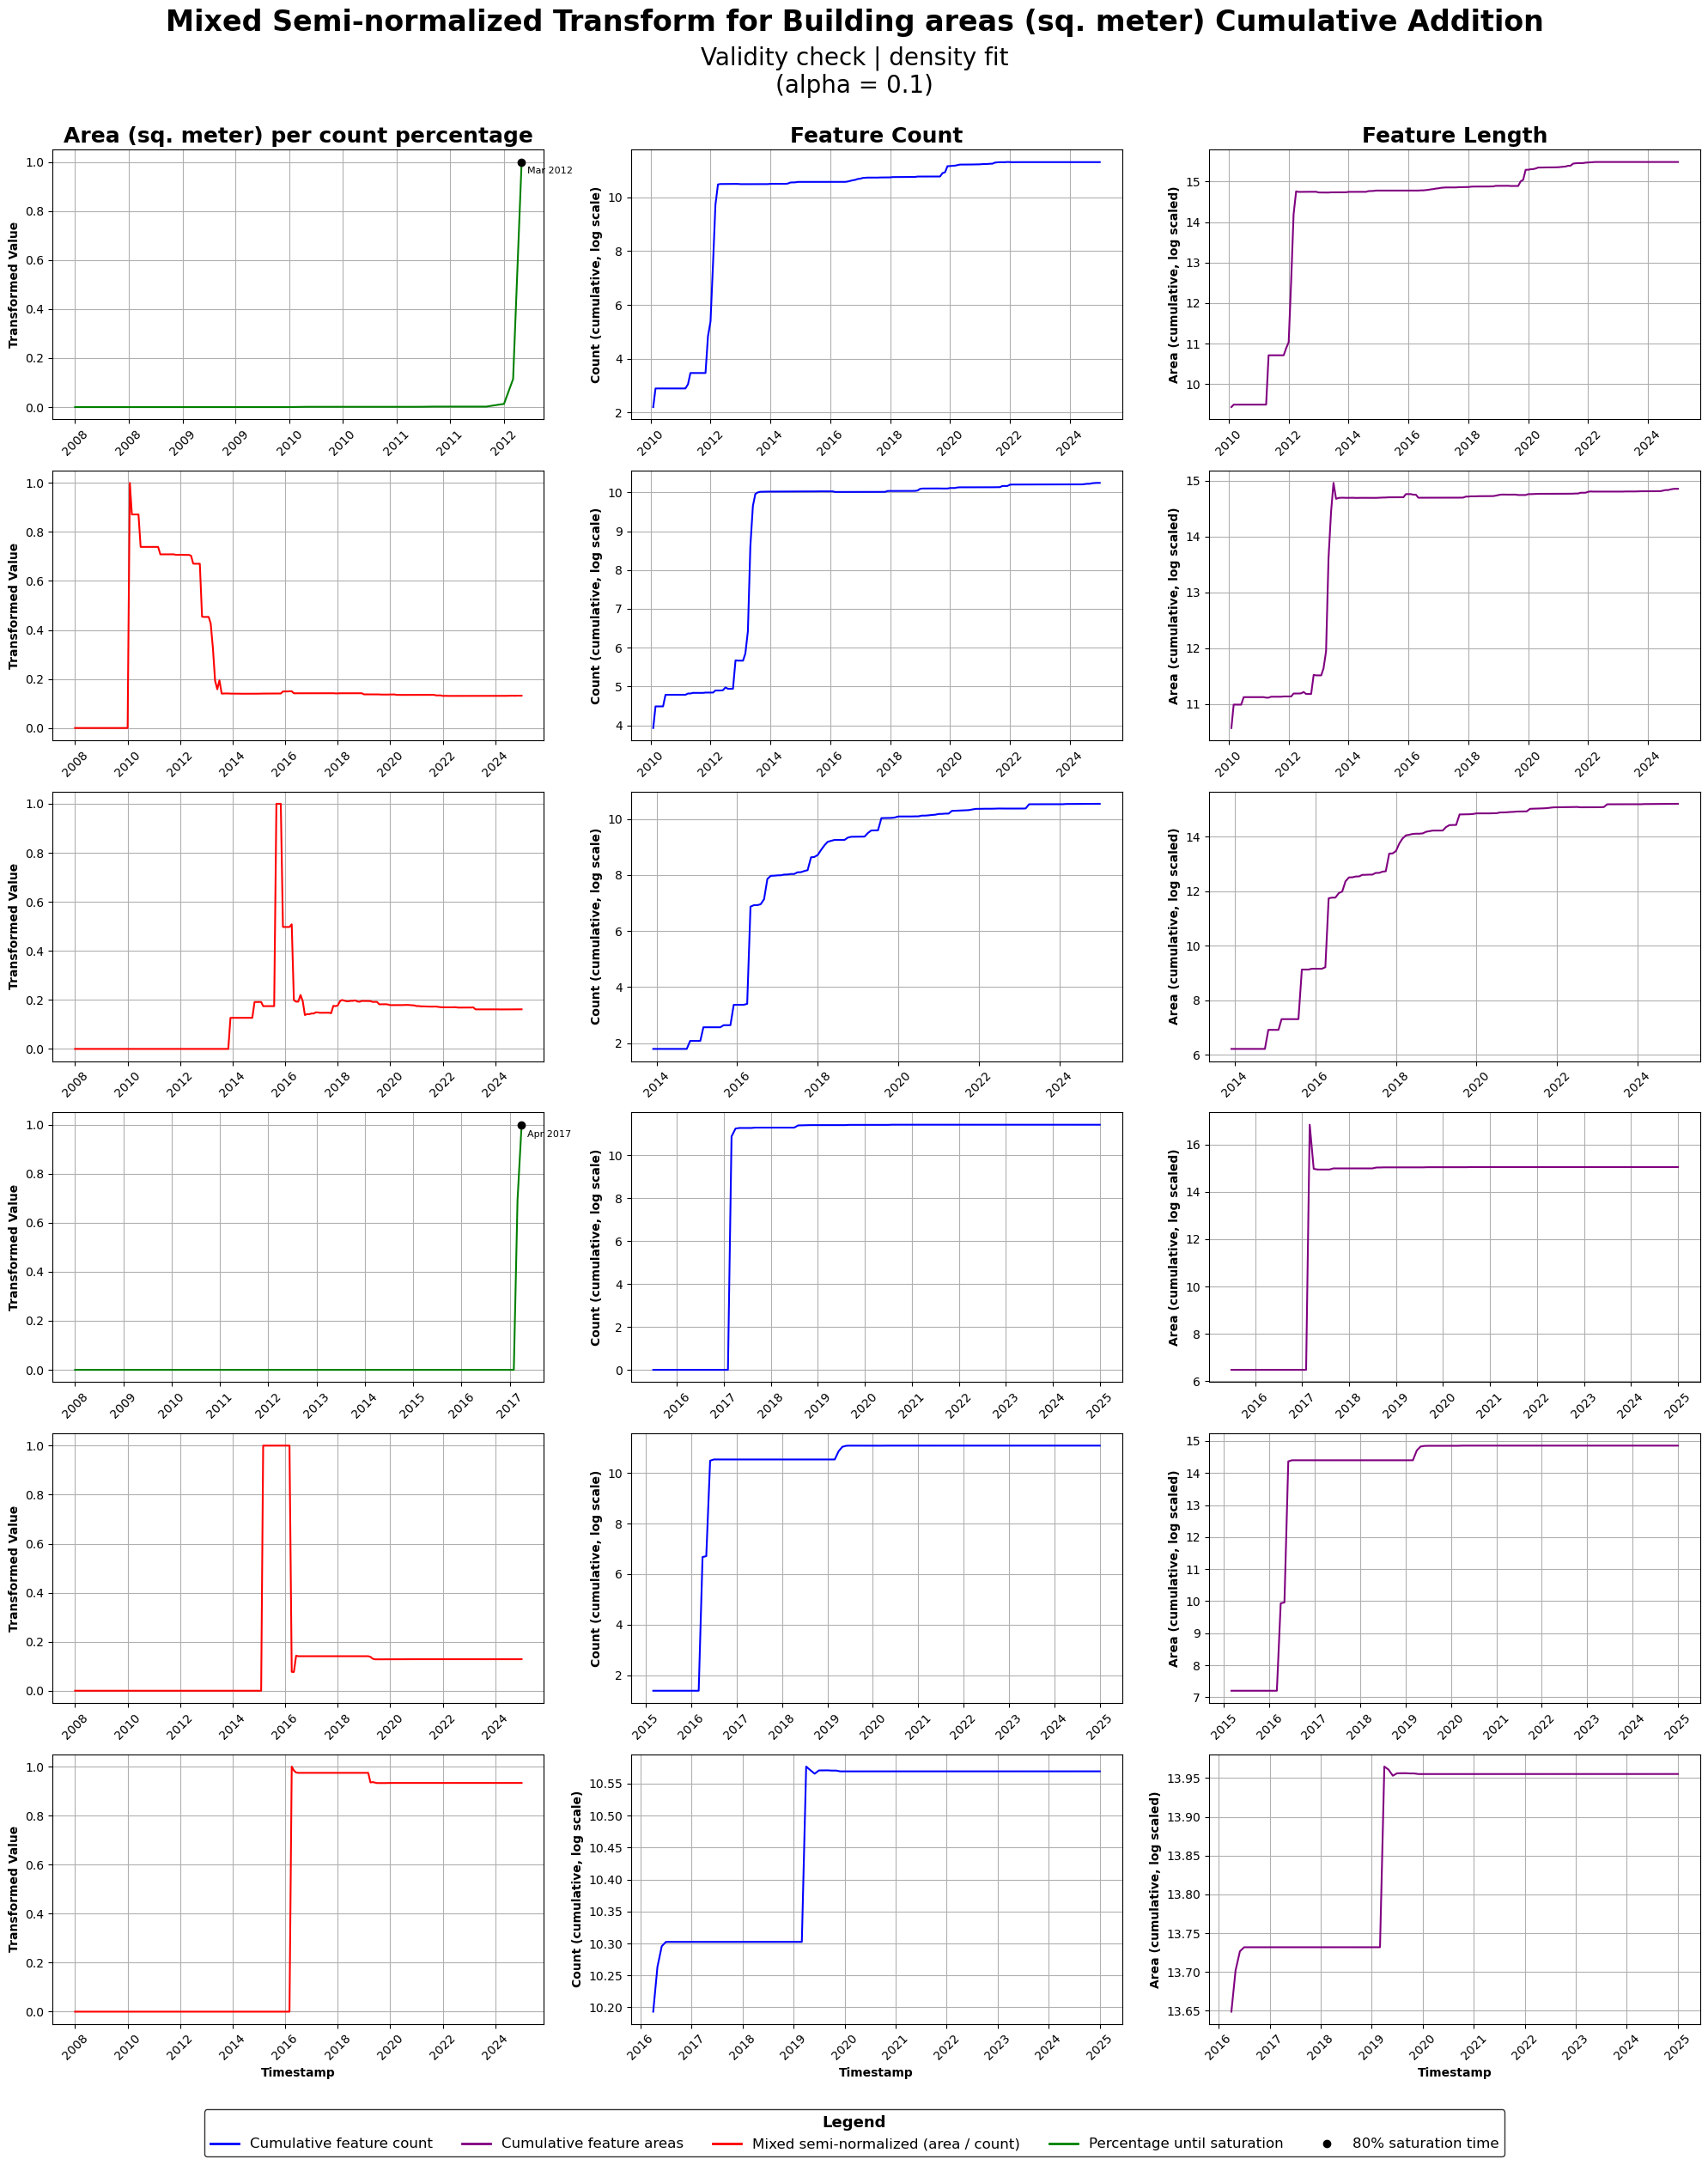

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


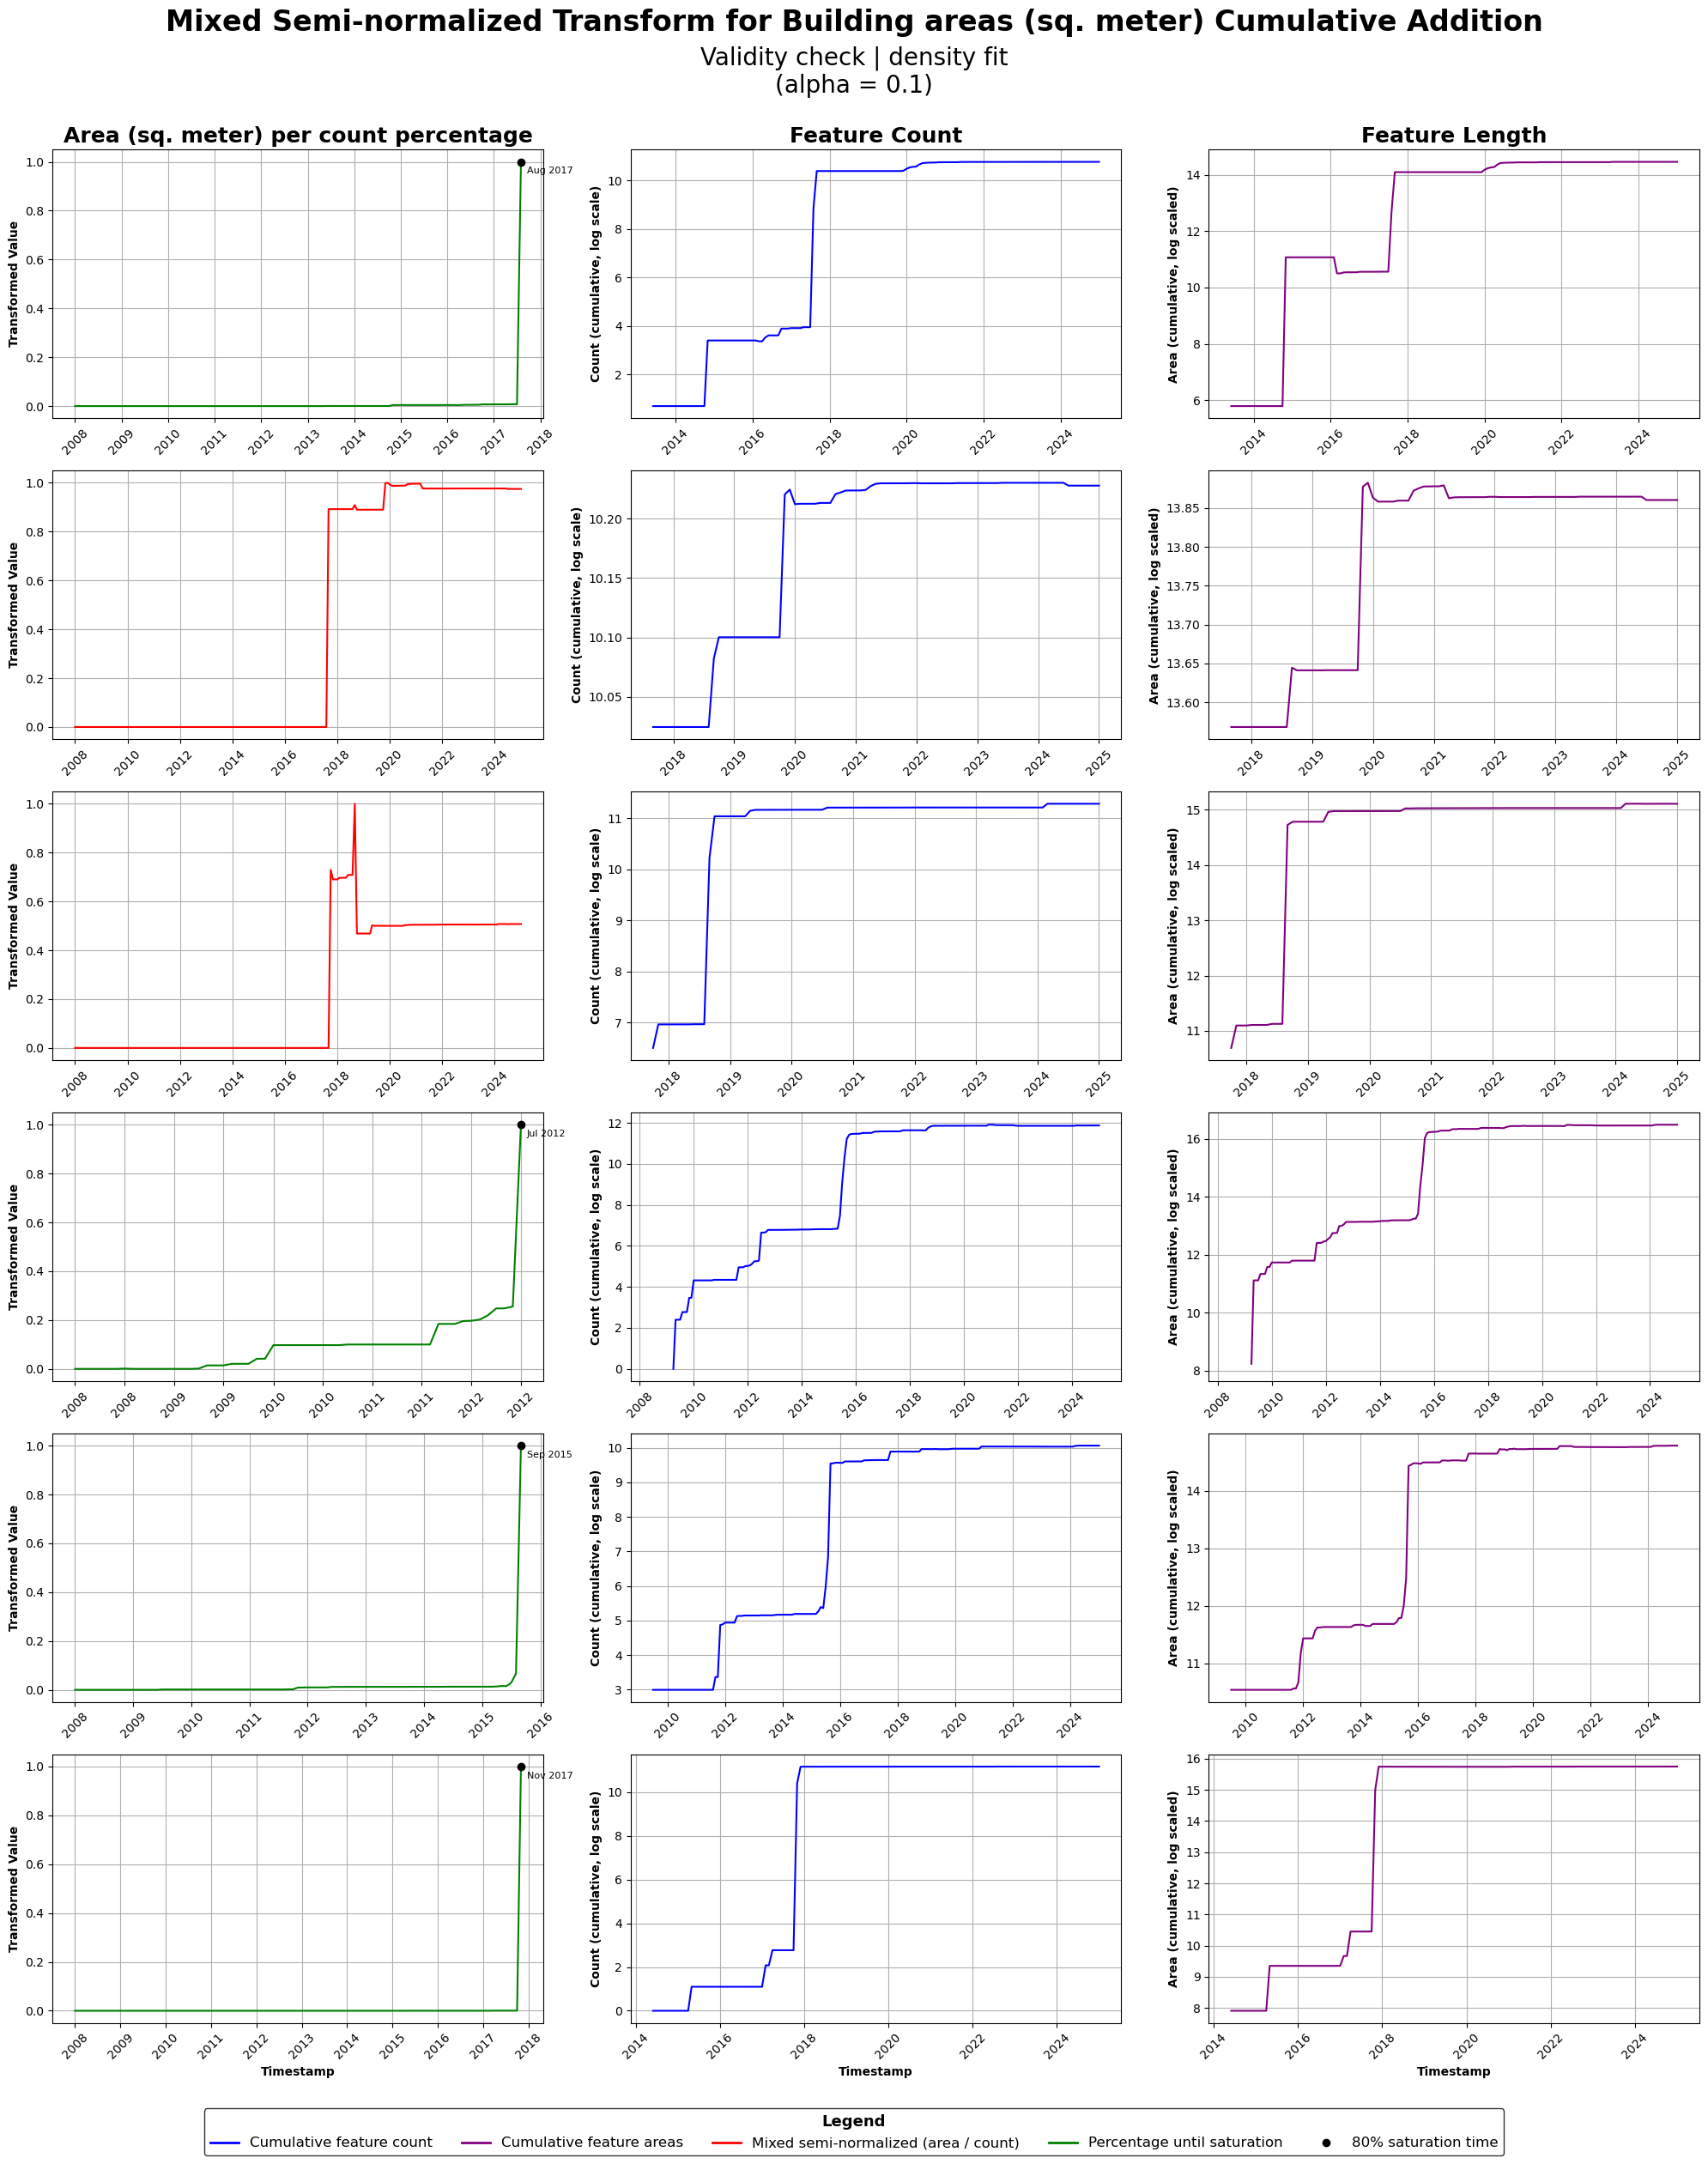

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


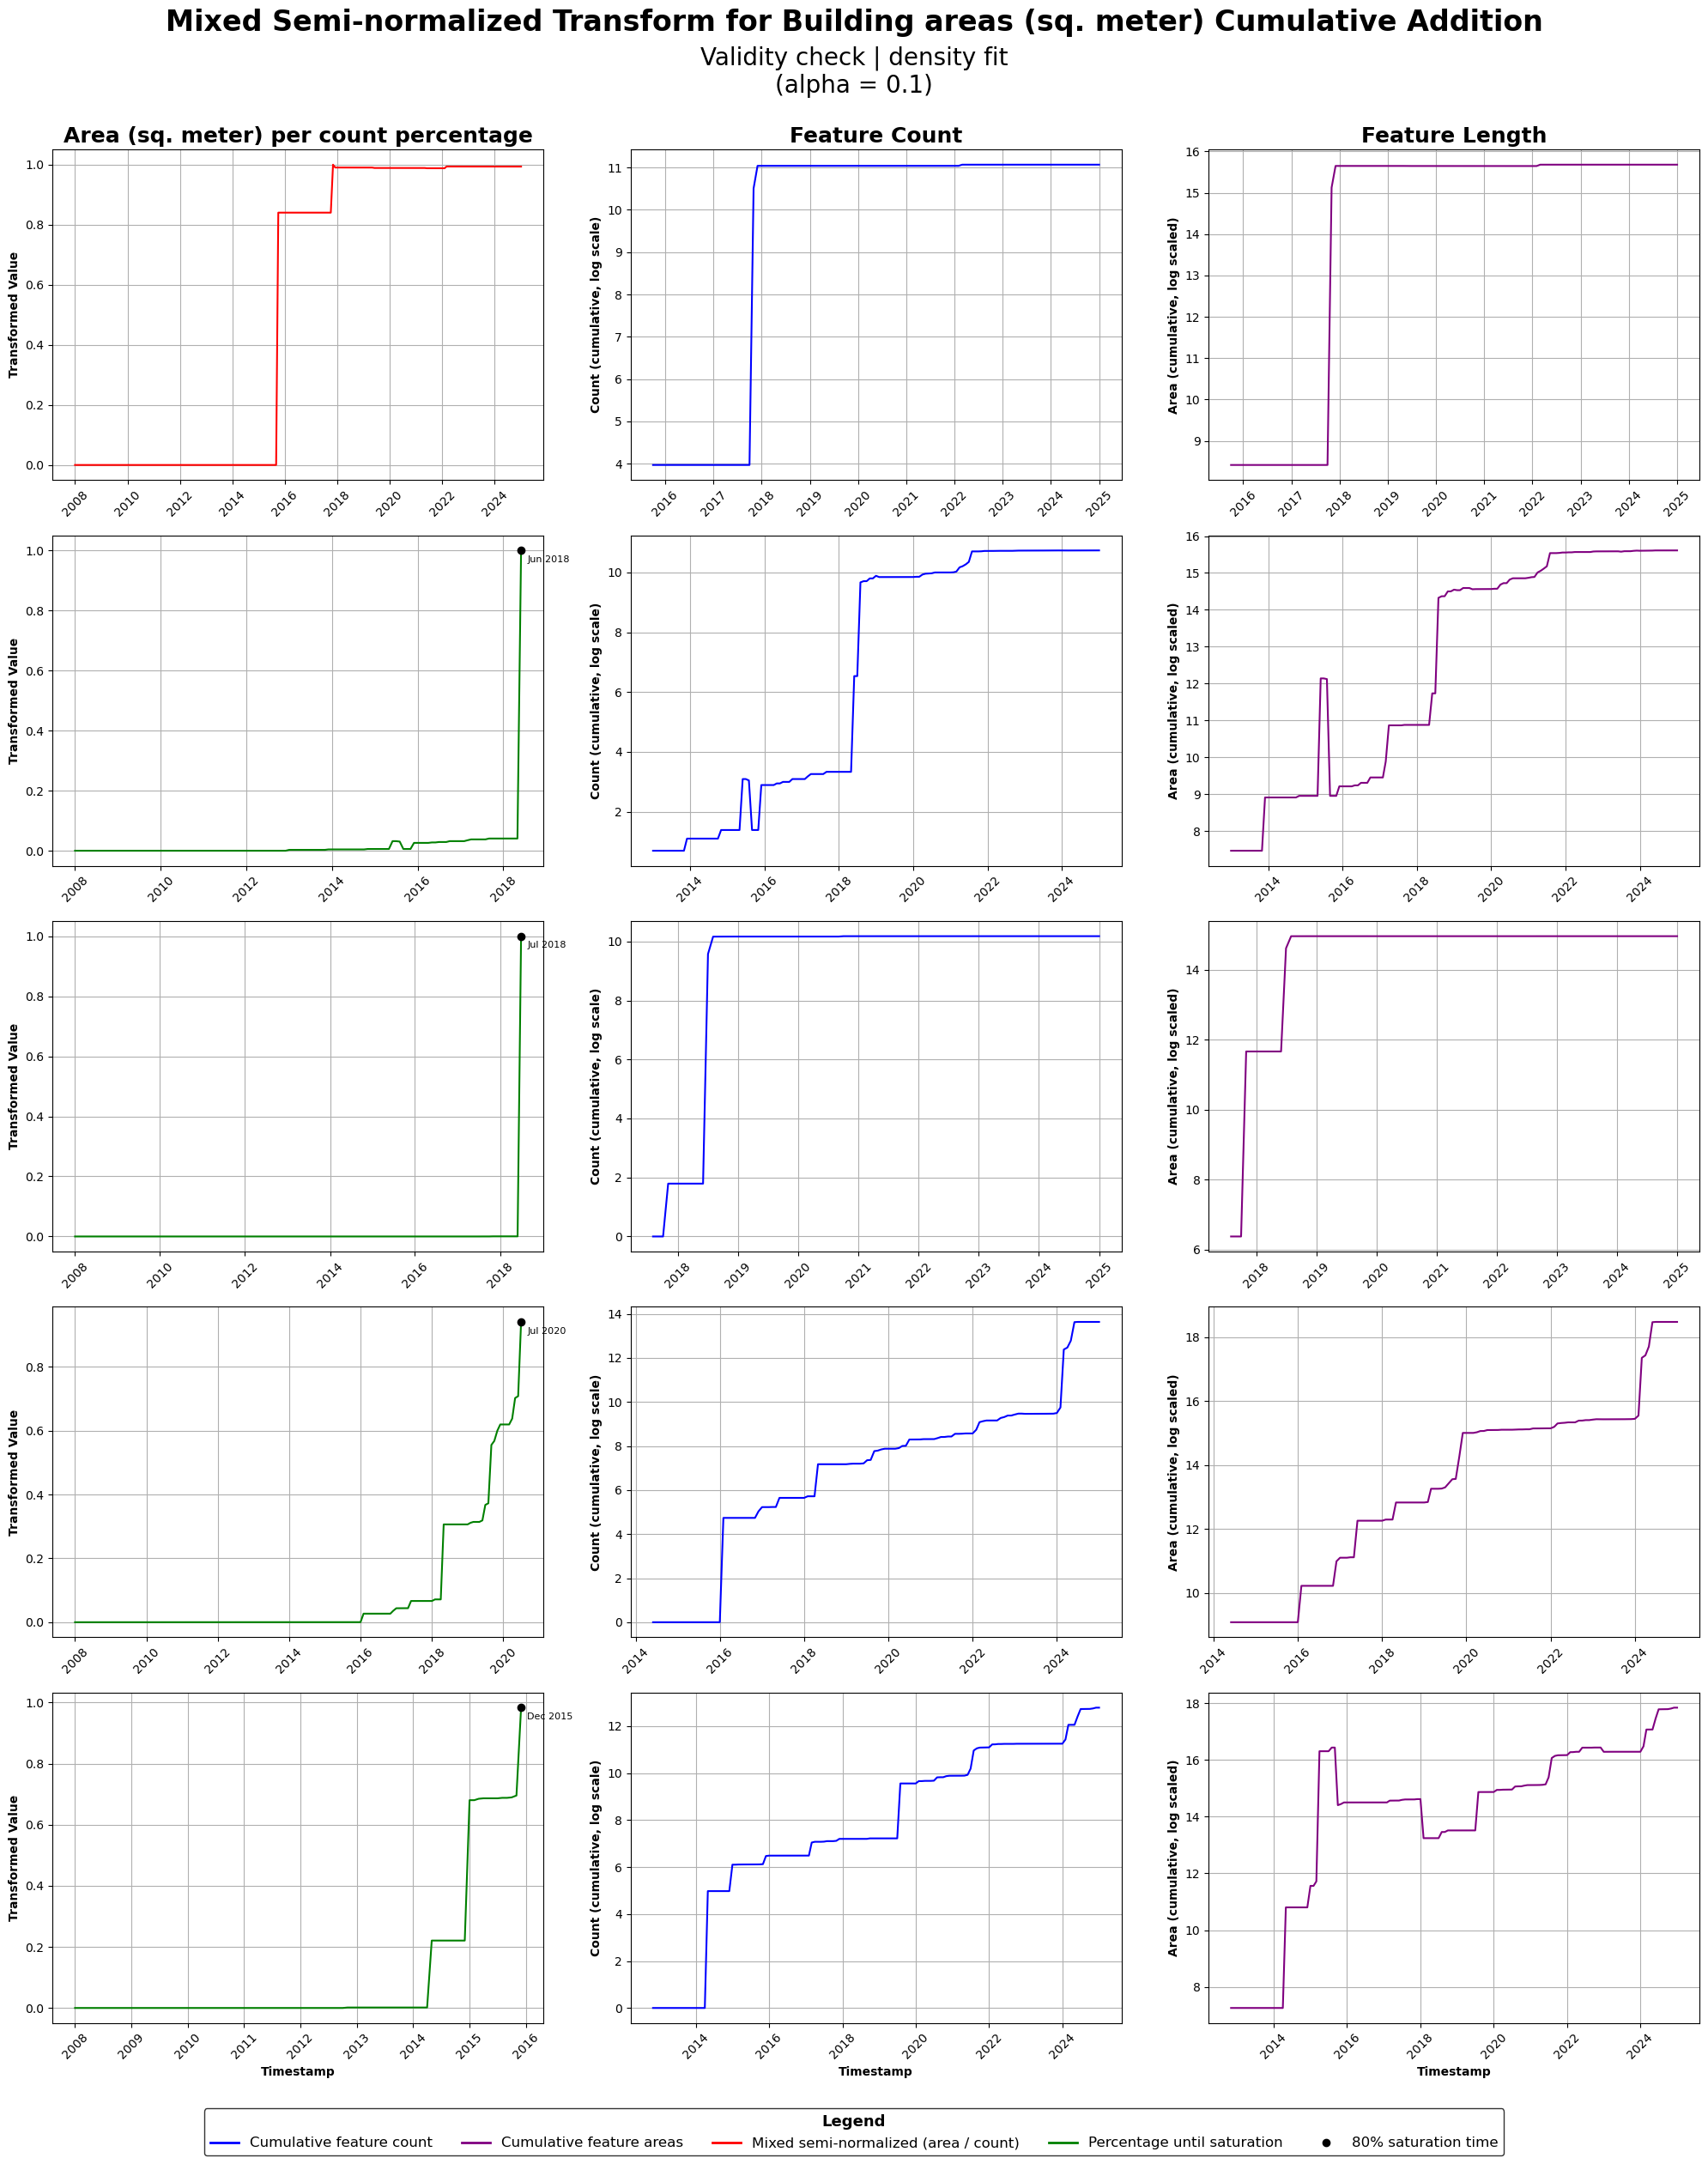

In [24]:
_ = generate_measure_sample_plot(bldgs_test[0:6], subtitle='Validity check | density fit\n(alpha = 0.1)', length=False).savefig(f'plots\\buildings_measure_density fit_1.png', dpi=300, bbox_inches='tight')
_ = generate_measure_sample_plot(bldgs_test[6:12], subtitle='Validity check | density fit\n(alpha = 0.1)', length=False).savefig(f'plots\\buildings_measure_density fit_2.png', dpi=300, bbox_inches='tight')
_ = generate_measure_sample_plot(bldgs_test[12:18], n=5, subtitle='Validity check | density fit\n(alpha = 0.1)', length=False).savefig(f'plots\\buildings_measure_density fit_3.png', dpi=300, bbox_inches='tight')